In [ ]:
# !pip install numpy pandas matplotlib control scipy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import control as ctl
import scipy.signal as sig
import os

def read_scope_waveform(path):
    
    with open(path, 'r') as f:
        lines = f.readlines()

    start = [i for i, line in enumerate(lines) if "Waveform Data" in line][0] + 1

    df = pd.read_csv(path, skiprows=start, header=None)

    return df[0].to_numpy()

def normalize_and_subsample(signals_dict):
    """
    Normaliza las señales en 'signals_dict' entre -1 y 1 y las submuestrea
    al tamaño de la señal más corta.

    Parámetros
    ----------
    signals_dict : dict[str, np.ndarray]
        Diccionario con nombre:vector de señales.

    Retorna
    -------
    t : np.ndarray
        Vector temporal normalizado (0 a 1) de longitud común.
    signals_norm : dict[str, np.ndarray]
        Diccionario con las señales normalizadas y submuestreadas.
    """
    # 1. Encontrar la longitud mínima
    min_len = min(len(sig) for sig in signals_dict.values())

    signals_norm = {}

    for name, sig in signals_dict.items():
        sig = np.asarray(sig, dtype=float)

        # 2. Normalizar entre -1 y 1
        sig_min, sig_max = sig.min(), sig.max()
        if sig_max != sig_min:
            sig_norm = 2 * (sig - sig_min) / (sig_max - sig_min) - 1
        else:
            sig_norm = np.zeros_like(sig)

        # 3. Submuestrear a min_len usando índices equiespaciados
        idx = np.linspace(0, len(sig) - 1, min_len).astype(int)
        sig_sub = sig_norm[idx]

        signals_norm[name] = sig_sub

    # 4. Crear vector temporal uniforme [0, 1]
    t = np.linspace(0, 1, min_len)

    return t, signals_norm

L = 6.81e-4
C = 1.96e-5
R = 6.1
Vin = 12

CWD = os.getcwd()
ROOT_DIR = os.path.join("..",CWD)
DATA_DIR = os.path.join(ROOT_DIR, "data-csv")

psim_df = pd.read_csv(os.path.join(DATA_DIR, 'psim-signal.csv'))

scope_sig = read_scope_waveform(os.path.join(DATA_DIR, 'scope-signal.csv'))

t_psim = np.array(psim_df['Time'])
Vout_psim = np.array(psim_df['Vout'])
Vsim_psim = np.array(psim_df['Vsim'])

s = ctl.TransferFunction.s
G = Vin / (L*C*s**2 + (L/R)*s + 1)
_, G_sig = ctl.step_response(G, T=t_psim)

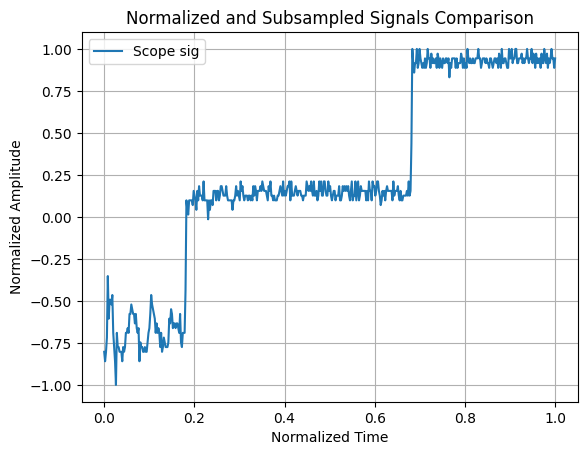

In [ ]:
signals_dict = {
    "PSIM-Vout": Vout_psim,
    "PSIM-Vsim": Vsim_psim,
    "G-sig": G_sig,
    "Scope-sig": scope_sig
}

t_generic, signals_norm = normalize_and_subsample(signals_dict)

plt.plot(t_generic, signals_norm["PSIM-Vout"], label='PSIM Vout')
plt.plot(t_generic, signals_norm["PSIM-Vsim"], label='PSIM Vsim')
plt.plot(t_generic, signals_norm["G-sig"], label='G sig')
plt.plot(t_generic, signals_norm["Scope-sig"], label='Scope sig')
plt.xlabel('Normalized Time')
plt.ylabel('Normalized Amplitude')
plt.title('Normalized and Subsampled Signals Comparison')
plt.legend()
plt.grid()
plt.show()